Total samples: 1984
Class 0 (baseball): 994
Class 1 (medical):  990

=== Classification Report ===
                    precision    recall  f1-score   support

rec.sport.baseball       0.97      0.97      0.97       194
           sci.med       0.97      0.98      0.97       203

          accuracy                           0.97       397
         macro avg       0.97      0.97      0.97       397
      weighted avg       0.97      0.97      0.97       397


Precision: 0.9706
Recall:    0.9754
F1 Score:  0.9730


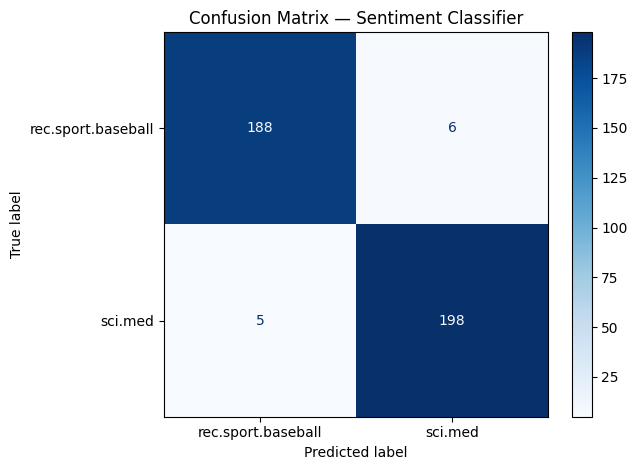

Confusion matrix saved.


In [5]:
# Day B-2: Sentiment Metrics — Precision, Recall, F1

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
)
import matplotlib.pyplot as plt

# Load a binary subset: "rec.sport.baseball" vs "sci.med"
# These are two clearly different topics — good for learning
categories = ["rec.sport.baseball", "sci.med"]
data = fetch_20newsgroups(subset="all", categories=categories, remove=("headers", "footers", "quotes"))

print(f"Total samples: {len(data.data)}")
print(f"Class 0 (baseball): {data.target.tolist().count(0)}")
print(f"Class 1 (medical):  {data.target.tolist().count(1)}")

# TF-IDF features (same as Day 1 — bag-of-words upgrade)
vectorizer = TfidfVectorizer(max_features=5000, stop_words="english")
X = vectorizer.fit_transform(data.data)
y = data.target

# Train/test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train logistic regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# --- METRICS ---
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=categories))

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"\nPrecision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

# --- CONFUSION MATRIX PLOT ---
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=categories)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix — Sentiment Classifier")
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()
print("Confusion matrix saved.")

## What is the precision of the model? What does that number mean in plain English?

The precision of the model is ```0.97```, that is ```97%```. The number means, in plain English, when the computer says, **"this is medical"** it's right 97 times out of 100. 

## What is the recall? What would a low recall mean in a medical diagnosis setting?

The recall is ```97%``` or ```0.9754```. A recall means of all the positives cases how many did the model catch. High recall is few missed detections. For medical diagnosis settings low recall means that there are high chances that  the model can miss important flags of diagnostic analysis for the patients that shouldn't be missed at all.

## Why is F1 higher than either precision or recall individually, or lower — explain what you observe.

F1 is the harmonic mean of precision and recall. That's why in this case the F1 score is higher than the precision and lower than the recall. It's a balanced version of both. It is a default metric in most NLP benchmarks. It actually generalizes the benchmark or threshold of precision and recall. 